In [77]:
using ITensors
using ITensorMPS
using PolyChaos
using Plots
using Observers
using LinearAlgebra
using DSP #for hilbert transform

In [17]:
function measure_SvN(; state, bond, half_sweep)
    if bond == 1 && half_sweep == 2
        return entanglement_entropy(state)
    end
    return nothing
end
function entanglement_entropy(ψ)
    # Compute the von Neumann entanglement entropy across each bond of the MPS
    N = length(ψ)
    SvN = zeros(N)
    psi = ψ
    for b=1:N
        psi = orthogonalize(psi, b)
        if b==1
            U,S,V = svd(psi[b] , siteind(psi, b))
        else
            U,S,V = svd(psi[b], (linkind(psi, b-1), siteind(psi, b)))
        end
        for n=1:ITensors.dim(S, 1)
            p = S[n,n]^2
            SvN[b] -= p * log2(p)
        end
    end
    return SvN
end

# Enrichment parameters
# T_enrich = 0                #Time in simulation where enrichment is used
# Kr_cutoff = 1e-10 #Numerical cutoff used for Krylov enrichment
# k1 = 3                     #Number of Krylov states used
# τ_Krylov = 1



entanglement_entropy (generic function with 1 method)

In [ ]:
function LB_current_v1(Γ_L,Γ_R,μ_L,μ_R,β_L,β_R,H_single,t_vec)
    """
    Calculate the particle current Jp using the Landauer-Büttiker formalism.
    """

    sys_inds = 2*N_bath+1:2*N_bath+N_sys

    wsamp = 10000; # Frequency sampling.
    eta = 0.005
    w = range(-10*D,10*D,wsamp); # Frequency axis for Landauer calculations (slightly larger than the band).
    dw = w[2] - w[1]; # Frequency increment.

    JR = (Γ_R/(2*π))*(heaviside(w .+ D) .- heaviside(w .- D))
    JL = (Γ_L/(2*π))*(heaviside(w .+ D) .- heaviside(w .- D))
    # Δ_L_test = -im*π*hilbert(JL)
    # Δ_R_test = -im*π*hilbert(JR)


    ##exact solution
    ρ = (1/(2*D))*(heaviside(w .+ D) .- heaviside(w .- D))
    Δ_L = (-Γ_L*D/(2*pi*D))*log.((w.-D .+im*eta)./(w .+D .+im*eta))
    Δ_R = (-Γ_R*D/(2*pi*D))*log.((w.-D .+im*eta)./(w .+D .+im*eta))

    M = complex(zeros(N_sys,N_sys))
    transmission_fn = complex(zeros(length(w)))

    coupling_factor = prod(abs.(t_vec).^2)
    HS = complex(H_single[sys_inds,sys_inds])
    detM_vec = []
    for (i,E) in enumerate(w)
        M = E*I - HS
        M[1,1] += -Δ_L[i]
        # M[1,1] += -Δ_L_test[i]
        M[N_sys,N_sys] += -Δ_R[i]
        #   M[N_sys,N_sys] += -Δ_R_test[i]
        detM = det(M)
        push!(detM_vec,detM)
        transmission_fn[i] = coupling_factor*4*(π^2)*JL[i]*JR[i]/(abs(detM)^2)
    end
    
    f_L = fermi_factor.(w,β_L,μ_L)#1 ./ (1 .+exp.((w .- μ_L)*β_L)); 
    f_R = fermi_factor.(w,β_R,μ_R)#1 ./ (1 .+exp.((w .- μ_R)*β_R));


    # Compute the particle-current
    Jp = (1/(2*π))*sum(transmission_fn.*(f_L - f_R))*dw;

    return Jp 
end
function LB_current_v2(Γ_L,Γ_R,μ_L,μ_R,β_L,β_R,H_single,t_vec)
    """
    Calculate the particle current Jp, energy current Je, and density n of a system 
    using the Landauer-Büttiker formalism.
    """

    # (;Γ_L,Γ_R,μ_L,μ_R,β_L,β_R,Ns,spec_fun_type,D,eta) = P
    # (;ϵi,ti) = DP


    wsamp = 10000; # Frequency sampling.
    w = range(-10*D,10*D,wsamp); # Frequency axis for Landauer calculations (slightly larger than the band).
    Γ = Γ_L+Γ_R
    dw = w[2] - w[1]; # Frequency increment.
    # if spec_fun_type == "box"
    #     ρ = (1/(2*D))*(heaviside(w .+ D) .- heaviside(w .- D))
    #     Δ_L = (-Γ_L*D/(2*pi*D))*log.((w.-D .+im*eta)./(w .+D .+im*eta))
    #     Δ_R = (-Γ_R*D/(2*pi*D))*log.((w.-D .+im*eta)./(w .+D .+im*eta))
    #     #Λ = -im*D*Γ*hilbert(ρ)

   # elseif spec_fun_type =="ellipse"
    ρ = (2/(π*D))*real(sqrt.(Complex.(1 .-(w/D).^2)))
    Δ_L = -im*D*Γ_L*hilbert(ρ)
    Δ_R = -im*D*Γ_R*hilbert(ρ)
   # end

    f_L = 1 ./ (1 .+exp.((w .- μ_L)*β_L)); 
    f_R = 1 ./ (1 .+exp.((w .- μ_R)*β_R));

    ####Calculate determinant of M matrix (Ns x Ns)
    if N_sys == 1
        Δ = Δ_L + Δ_R
        detM = w .- ϵ_vec[1] .- Δ
        G = 1 ./detM
        A_den = (-1/π).*imag.(G)    
    elseif N_sys == 2
        detM = (w .-ϵ_vec[1] .-Δ_L).*(w.-ϵ_vec[2].-Δ_R)
        detM = detM .- abs.(t_vec[1]^2) 
        G = ((w .-ϵ_vec[2] .-Δ_R))./detM
        A_den = (-1/π).*imag.(G)    
    elseif N_sys == 3
        detM = (w .-ϵ_vec[1] .-Δ_L).*(w.-ϵ_vec[3].-Δ_R).*(w.-ϵ_vec[2])
        detM = detM - (abs.(t_vec[2])^2)*(w.-ϵ_vec[1].-Δ_L)
        detM = detM - (abs.(t_vec[1])^2)*(w.-ϵ_vec[3].-Δ_R)
        G =  (w .-ϵ_vec[1] .-Δ_L).*(w.-ϵ_vec[3].-Δ_R)./detM
        A_den = (-1/π)*imag.(G)
    end

    A = (D*Γ*ρ/π) ./(abs.(detM).^2)
    if length(t_vec)>0
        coupling_factor = prod(abs.(t_vec).^2)
        A = A.*coupling_factor
    end    
    f_L = 1 ./ (1 .+exp.((w .- μ_L)*β_L)); 
    f_R = 1 ./ (1 .+exp.((w .- μ_R)*β_R));

    prefactor = (4*π*D*Γ_L*D*Γ_R)/(2*π*D*Γ)
    # Compute the particle-current, energy-current and density:
    Jp = prefactor*sum(ρ.*A.*(f_L - f_R))*dw;

    return Jp
end



LB_current (generic function with 1 method)

In [145]:
function thermofield_spectral_function(w,Γ,β,μ,filled_or_empty)
    
    ##for simplicity, we use a box spectral function
    #J = (Γ/(2*π))*(heaviside(w .+ D) .- heaviside(w .- D))


    ρ = real((2/(π*D))*sqrt.(Complex.(1 .-(w/D).^2)))
    J =  (Γ*D/π)*ρ


    if filled_or_empty == "filled"
        J = J .* fermi_factor(w,β,μ)
    elseif filled_or_empty == "empty"
        J = J .* (1 .- fermi_factor(w,β,μ))
    end
    return J
end
function chain_mapping(filled_or_empty,N_bath,Γ,β,μ,D)

    couplings,energies = complex(zeros(N_bath)),complex(zeros(N_bath))
    spec_fun(t) = thermofield_spectral_function(t,Γ,β,μ,filled_or_empty)
    supp = (-2*D,2*D)
    my_meas = Measure("my_meas", spec_fun, supp, false, Dict())
    my_op = OrthoPoly("my_op", N_bath-1, my_meas; Nquad=100000);
    α_coeffs,β_coeffs = coeffs(my_op)[:,1],coeffs(my_op)[:,2]
    energies = α_coeffs
    couplings = sqrt.(β_coeffs)
    return energies,couplings
end
function initialise_Hamiltonian(MPS_siteinds,N_sys,N_bath,β_L,μ_L,β_R,μ_R,D,ϵ_vec,t_vec;kwargs...)

    #total length of the MPS
    N = length(MPS_siteinds)
    
    #initialise single particle hamiltonian
    H_single = zeros(N,N)

    #indices for different parts of the chain
    left_bath_filled_inds = 1:2:2*N_bath
    left_bath_empty_inds = 2:2:2*N_bath
    sys_inds = 2*N_bath+1:2*N_bath+N_sys
    right_bath_filled_inds = 2*N_bath+N_sys+1:2:N
    right_bath_empty_inds = 2*N_bath+N_sys+2:2:N

    #Creating chain coefficients
    energies_L_filled,couplings_L_filled = chain_mapping("filled",N_bath,Γ_L,β_L,μ_L,D)
    energies_L_empty,couplings_L_empty = chain_mapping("empty",N_bath,Γ_L,β_L,μ_L,D)
    energies_R_filled,couplings_R_filled = chain_mapping("filled",N_bath,Γ_R,β_R,μ_R,D)
    energies_R_empty,couplings_R_empty = chain_mapping("empty",N_bath,Γ_R,β_R,μ_R,D)

    MPO_terms = OpSum()

    """
    Left bath terms
    """

    ##As the loop goes from left to right along the chain, the coefficents need to be reversed.
    energies_L_filled,couplings_L_filled = reverse(energies_L_filled),reverse(couplings_L_filled)
    energies_L_empty,couplings_L_empty = reverse(energies_L_empty),reverse(couplings_L_empty)
    for i = 1:N_bath

        ##energies for filled chain
        MPO_terms += energies_L_filled[i],"N",left_bath_filled_inds[i]
        H_single[left_bath_filled_inds[i],left_bath_filled_inds[i]] = energies_L_filled[i]

        ##energies for empty chain
        MPO_terms += energies_L_empty[i],"N",left_bath_empty_inds[i] 
        H_single[left_bath_empty_inds[i],left_bath_empty_inds[i]] = energies_L_empty[i]

        if i <N_bath
            ##hopping site i to i+1 (filled chain)
            MPO_terms += couplings_L_filled[i+1],"Cdag",left_bath_filled_inds[i],"C",left_bath_filled_inds[i+1] 
            H_single[left_bath_filled_inds[i],left_bath_filled_inds[i+1]] = couplings_L_filled[i+1]

            ##hopping site i+1 to i (filled chain)
            MPO_terms += couplings_L_filled[i+1],"Cdag",left_bath_filled_inds[i+1],"C",left_bath_filled_inds[i] 
            H_single[left_bath_filled_inds[i+1],left_bath_filled_inds[i]] = couplings_L_filled[i+1]

            ##hopping site i to i+1 (empty chain)
            MPO_terms += couplings_L_empty[i+1],"Cdag",left_bath_empty_inds[i],"C",left_bath_empty_inds[i+1] 
            H_single[left_bath_empty_inds[i],left_bath_empty_inds[i+1]] = couplings_L_empty[i+1]

            ##hopping site i+1 to i (empty chain)
            MPO_terms += couplings_L_empty[i+1],"Cdag",left_bath_empty_inds[i+1],"C",left_bath_empty_inds[i] 
            H_single[left_bath_empty_inds[i+1],left_bath_empty_inds[i]] = couplings_L_empty[i+1]
        end 
    end

    """
    Left bath to system coupling terms
    """

    ##hopping from left bath to system (filled chain)
    MPO_terms +=  couplings_L_filled[end],"Cdag",left_bath_filled_inds[end],"C",sys_inds[1] 
    H_single[left_bath_filled_inds[end],sys_inds[1]] = couplings_L_filled[end]

    ##hopping from system to left bath (filled chain)
    MPO_terms += couplings_L_filled[end],"Cdag",sys_inds[1],"C",left_bath_filled_inds[end] 
    H_single[sys_inds[1],left_bath_filled_inds[end]] = couplings_L_filled[end]
    
    ##hopping from left bath to system (empty chain)
    MPO_terms +=  couplings_L_empty[end],"Cdag",left_bath_empty_inds[end],"C",sys_inds[1] 
    H_single[left_bath_empty_inds[end],sys_inds[1]] = couplings_L_empty[end]

    ##hopping from system to left bath (empty chain)
    MPO_terms += couplings_L_empty[end],"Cdag",sys_inds[1],"C",left_bath_empty_inds[end] 
    H_single[sys_inds[1],left_bath_empty_inds[end]] = couplings_L_empty[end]


    """
    System terms
    """

    for i =1:N_sys
        #energies
        MPO_terms += ϵ_vec[i],"N",sys_inds[i]
        H_single[sys_inds[i],sys_inds[i]] = ϵ_vec[i]
        if i<N_sys
            #hoppings
            MPO_terms += t_vec[i],"Cdag",sys_inds[i],"C",sys_inds[i+1]
            H_single[sys_inds[i],sys_inds[i+1]] = t_vec[i]

            MPO_terms += t_vec[i],"Cdag",sys_inds[i+1],"C",sys_inds[i]
            H_single[sys_inds[i+1],sys_inds[i]] = t_vec[i]
            
            #interactions
            MPO_terms += U_vec[i],"n",sys_inds[i],"n",sys_inds[i+1]

        end
    end


    """
    Right bath to system coupling terms
    """

    ##hopping from right bath to system (filled chain)
    MPO_terms +=  couplings_R_filled[1],"Cdag",right_bath_filled_inds[1],"C",sys_inds[end] 
    H_single[right_bath_filled_inds[1],sys_inds[end]] = couplings_R_filled[1]

    ##hopping from system to right bath (filled chain)
    MPO_terms += couplings_R_filled[1],"Cdag",sys_inds[end],"C",left_bath_filled_inds[1] 
    H_single[sys_inds[end],right_bath_filled_inds[1]] = couplings_R_filled[1]
    
    ##hopping from right bath to system (empty chain)
    MPO_terms +=  couplings_R_empty[1],"Cdag",right_bath_empty_inds[1],"C",sys_inds[end] 
    H_single[right_bath_empty_inds[1],sys_inds[end]] = couplings_R_empty[1]

    ##hopping from system to right bath (empty chain)
    MPO_terms += couplings_R_empty[1],"Cdag",sys_inds[end],"C",right_bath_empty_inds[1] 
    H_single[sys_inds[end],right_bath_empty_inds[1]] = couplings_R_empty[1]

    """
    Right bath terms
    """

    for i = 1:N_bath
        ##energies for filled chain
        MPO_terms += energies_R_filled[i],"N",right_bath_filled_inds[i]
        H_single[right_bath_filled_inds[i],right_bath_filled_inds[i]] = energies_R_filled[i]

        ##energies for empty chain
        MPO_terms += energies_R_empty[i],"N",right_bath_empty_inds[i] 
        H_single[right_bath_empty_inds[i],right_bath_empty_inds[i]] = energies_R_empty[i]


        if i <N_bath
             ##hopping site i to i+1 (filled chain)
            MPO_terms += couplings_R_filled[i+1],"Cdag",right_bath_filled_inds[i],"C",right_bath_filled_inds[i+1]
            H_single[right_bath_filled_inds[i],right_bath_filled_inds[i+1]] = couplings_R_filled[i+1]

            ##hopping site i+1 to i (filled chain)
            MPO_terms += couplings_R_filled[i+1],"Cdag",right_bath_filled_inds[i+1],"C",right_bath_filled_inds[i] 
            H_single[right_bath_filled_inds[i+1],right_bath_filled_inds[i]] = couplings_R_filled[i+1]

            ##hopping site i to i+1 (empty chain)
            MPO_terms += couplings_R_empty[i+1],"Cdag",right_bath_empty_inds[i],"C",right_bath_empty_inds[i+1] 
            H_single[right_bath_empty_inds[i],right_bath_empty_inds[i+1]] = couplings_R_empty[i+1]

            ##hopping site i+1 to i (empty chain)
            MPO_terms += couplings_R_empty[i+1],"Cdag",right_bath_empty_inds[i+1],"C",right_bath_empty_inds[i] 
            H_single[right_bath_empty_inds[i+1],right_bath_empty_inds[i]] = couplings_R_empty[i+1]
        end
    end

    H_MPO = MPO(MPO_terms,MPS_siteinds)

    return H_MPO,H_single
end
function current_time(; current_time, bond, half_sweep)
    if bond == 1 && half_sweep == 2
    return real(im*current_time)
    end
    return nothing
end
function measure_correlation_matrix(; state, bond, half_sweep)
    if bond==1 && half_sweep == 2
        return transpose(correlation_matrix(state,"Cdag","C"))
    end
    return nothing
end
function propagate_correlations(corr0,H_single,times)
    """
    The correlation matrix C_ij = expect(cdag[j]*c[i]) propagates according to
    C_ij(t) =U*C_ij(0)*U', but G_ij = expect(cdag[i]*c[j]) doesn't.
    """
    δt = times[2] - times[1]
    U_step = exp(-im*δt*H_single)

    corrs = Vector{Any}(undef,length(times))
    corrs[1] = U_step*corr0*U_step'
    for i in 2:length(times)
        corrs[i] = U_step*corrs[i-1]*U_step'
    end
    return corrs
end

heaviside(t) = 0.5 * (sign.(t) .+ 1)
fermi_factor(w,β,μ) =  1 ./(exp.(β*(w .- μ)).+ 1)

"""
Parameters
"""
#bath parameters
N_bath = 100             #number of bath modes
β_L = 10.0               #inverse temperature for left bath
μ_L = 0.1               #chemical potential for left bath
Γ_L = 0.005               #system-bath coupling strength for left bath
β_R = 10.0               #inverse temperature for right bath
μ_R = 0.1#-0.1               #chemical potential for right bath
Γ_R = 0.005               #system-bath coupling strength for right bath
D = 1                   #bandwidth

#system parameters
N_sys = 1               #system size
ϵ_vec = [0]#[0.0, 0.0]      #system on-site energies
t_vec = [0]#[0.1]           #system hopping terms
U_vec = [0]#[0.0]


#tdvp_parameters
tdvp_cutoff = 1e-7 #Numerical cutoff for tdvp
minbonddim = 1      #Minimum bond dimension for tdvp 
maxbonddim = 2       #Maximum bond dimension for tdvp
δt = 0.1            #Time step
T = 70               #Evolution time
times = range(δt,stop = T,step = δt)


"""
Create initial MPS
"""

#initial occupation
bath_occs = [isodd(i) ? "Emp" : "Occ" for i=1:2*N_bath]
sys_occs = repeat(["Emp"],N_sys)
total_occs = [bath_occs;sys_occs;bath_occs]

#Creating MPS siteindices
MPS_siteinds = siteinds("Fermion",N_sys+4*N_bath,conserve_qns=true)

#creating initial MPS
ψ0 = MPS(ComplexF64,MPS_siteinds,total_occs) ##put in minimum bond dimension

"""
Create Hamiltonianm both single particle and many body MPO
"""

H_MPO,H_single = initialise_Hamiltonian(MPS_siteinds,N_sys,N_bath,β_L,μ_L,β_R,μ_R,D,ϵ_vec,t_vec)



"""
TDVP
"""

# #create observer for tdvp
# obs = Observer("times" => current_time,"corr" => measure_correlation_matrix)


# ψT = tdvp(H_MPO, -im * T, ψ0; 
# time_step = -im * δt,
# cutoff = tdvp_cutoff, 
# mindim = minbonddim, 
# maxdim = maxbonddim, 
# outputlevel = 1, 
# observer! = obs)

"""
Exact correlation matrix evolution (only valid for U=0)
"""
corr0 = transpose(correlation_matrix(ψ0,"Cdag","C"))
exact_corrs = propagate_correlations(corr0,H_single,times);

In [130]:
energies_L_filled,couplings_L_filled = chain_mapping("filled",N_bath,Γ_L,β_L,μ_L,D)
energies_L_empty,couplings_L_empty = chain_mapping("empty",N_bath,Γ_L,β_L,μ_L,D)
energies_R_filled,couplings_R_filled = chain_mapping("filled",N_bath,Γ_R,β_R,μ_R,D)
energies_R_empty,couplings_R_empty = chain_mapping("empty",N_bath,Γ_R,β_R,μ_R,D)
couplings_R_filled


10-element Vector{Float64}:
 0.08344887454436294
 0.2715532043895505
 0.3222411759009732
 0.38832838645876633
 0.4462854933994811
 0.4818613845056946
 0.49586243149780634
 0.49934673333832447
 0.4999249008985874
 0.49999340178907264

In [139]:
H_single[2*N_bath-1:2*N_bath+3,2*N_bath-1:2*N_bath+3]

5×5 Matrix{Float64}:
 -0.354012   0.0        0.0946138  0.0         0.0
  0.0        0.455079   0.0834489  0.0         0.0
  0.0946138  0.0834489  0.0        0.1         0.0
  0.0        0.0        0.1        0.0         0.0834489
  0.0        0.0        0.0        0.0834489  -0.455079

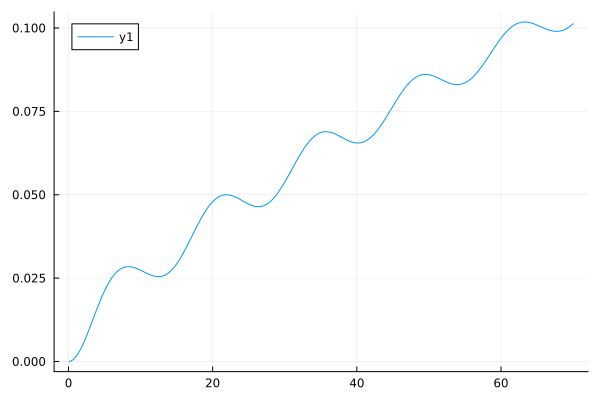

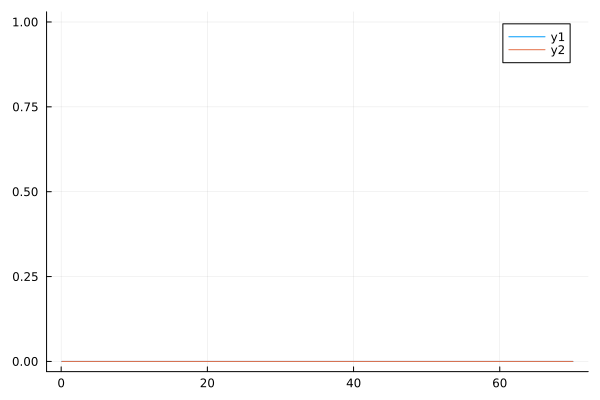

In [146]:
##Plotting density against time for the chosen site

sys_site = 1
MPS_site = 2*N_bath+sys_site
#tdvp_den = [corr[MPS_site,MPS_site] for corr in obs.corr] 
exact_den = real.([corr[MPS_site,MPS_site] for corr in exact_corrs])


exact_currents = real.([im*(t_vec[sys_site]*corr[MPS_site,MPS_site+1] - t_vec[sys_site]*corr[MPS_site+1,MPS_site]) for corr in exact_corrs])


#Plots.plot(times,real.(tdvp_den))
display(Plots.plot(times,real.(exact_den)))

Plots.plot(times,exact_currents)
Plots.plot!(times,real.(LB_current(Γ_L,Γ_R,μ_L,μ_R,β_L,β_R,H_single,t_vec)*ones(length(times))))
